In [4]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from xgboost import XGBRegressor

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


In [5]:

df = pd.read_csv(r'D:\Uniliver Limited\vehicle_price_prediction\dataset.csv')

In [6]:
df.head()
df.tail()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1002 entries, 0 to 1001
Data columns (total 17 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   name            1002 non-null   object 
 1   description     946 non-null    object 
 2   make            1002 non-null   object 
 3   model           1002 non-null   object 
 4   year            1002 non-null   int64  
 5   price           979 non-null    float64
 6   engine          1000 non-null   object 
 7   cylinders       897 non-null    float64
 8   fuel            995 non-null    object 
 9   mileage         968 non-null    float64
 10  transmission    1000 non-null   object 
 11  trim            1001 non-null   object 
 12  body            999 non-null    object 
 13  doors           995 non-null    float64
 14  exterior_color  997 non-null    object 
 15  interior_color  964 non-null    object 
 16  drivetrain      1002 non-null   object 
dtypes: float64(4), int64(1), object(1

In [7]:
df.describe()

,year,price,cylinders,mileage,doors
count,1002.000000,979.000000,897.000000,968.000000,995.000000
mean,2023.916168,50202.985700,4.975474,69.033058,3.943719
std,0.298109,18700.392062,1.392526,507.435745,0.274409
min,2023.000000,0.000000,0.000000,0.000000,2.000000
25%,2024.000000,36600.000000,4.000000,4.000000,4.000000
50%,2024.000000,47165.000000,4.000000,8.000000,4.000000
75%,2024.000000,58919.500000,6.000000,13.000000,4.000000
max,2025.000000,195895.000000,8.000000,9711.000000,5.000000


In [8]:
pd.isnull(df).sum()

name                0
description        56
make                0
model               0
year                0
price              23
engine              2
cylinders         105
fuel                7
mileage            34
transmission        2
trim                1
body                3
doors               7
exterior_color      5
interior_color     38
drivetrain          0
dtype: int64

In [9]:
print(df['cylinders'].min())
print(df['cylinders'].max())

0.0
8.0


In [10]:
df_dropped = df.dropna(subset=['price'])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1002 entries, 0 to 1001
Data columns (total 17 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   name            1002 non-null   object 
 1   description     946 non-null    object 
 2   make            1002 non-null   object 
 3   model           1002 non-null   object 
 4   year            1002 non-null   int64  
 5   price           979 non-null    float64
 6   engine          1000 non-null   object 
 7   cylinders       897 non-null    float64
 8   fuel            995 non-null    object 
 9   mileage         968 non-null    float64
 10  transmission    1000 non-null   object 
 11  trim            1001 non-null   object 
 12  body            999 non-null    object 
 13  doors           995 non-null    float64
 14  exterior_color  997 non-null    object 
 15  interior_color  964 non-null    object 
 16  drivetrain      1002 non-null   object 
dtypes: float64(4), int64(1), object(1

In [11]:
# Dropping the description as this will not be usefull for the analysis
df_dropped = df_dropped.drop('description', axis = 1)


In [12]:
# print(df['make'].unique())
# print(df['model'].unique()) 
# print(df['mileage'].unique()) 
# print(df['cylinders'].unique())
# print(df['interior_color'].unique())


In [13]:
print(df_dropped[['make','model','mileage','cylinders','interior_color']])

               make           model  mileage  cylinders    interior_color
0              Jeep        Wagoneer     10.0        6.0      Global Black
1              Jeep  Grand Cherokee      1.0        6.0      Global Black
2               GMC        Yukon XL      0.0        8.0  Teak/Light Shale
3             Dodge         Durango     32.0        8.0             Black
4               RAM            3500     10.0        6.0             Black
...             ...             ...      ...        ...               ...
997   Mercedes-Benz   Sprinter 2500     10.0        4.0             Black
998           Dodge          Hornet      0.0        4.0             Black
999            Jeep        Wagoneer     20.0        6.0             Black
1000         Nissan          Murano      6.0        6.0          Graphite
1001      Chevrolet  Silverado 2500     31.0        8.0         Jet Black

[979 rows x 5 columns]


In [14]:
pd.isnull(df).sum()
df_dropped[['mileage','cylinders','interior_color']].isnull().sum()

mileage            34
cylinders         102
interior_color     37
dtype: int64

In [15]:

# Replacing the mileage values in the dataset with grouped imputation
# GROUPED IMPUTATION FOR mileage (median per make+model)
#    - First try median by (make, model)
#    - If still NaN, fill with overall median
# ---------------------------------------------------
# ensure numeric
df_dropped['mileage'] = pd.to_numeric(df_dropped['mileage'], errors='coerce')

# group-wise median fill
df_dropped['mileage'] = df_dropped.groupby(['make', 'model'])['mileage'].transform(
    lambda x: x.fillna(x.median())
)

# global median fallback
global_mileage_median = df_dropped['mileage'].median()
df_dropped['mileage'] = df_dropped['mileage'].fillna(global_mileage_median)

In [16]:
df_dropped[['mileage','cylinders','interior_color']].isnull().sum()


mileage             0
cylinders         102
interior_color     37
dtype: int64

In [17]:

# Handling cylinder missing values
# Replacing the cylinders with mode and global mode
def fill_mode_per_group(series, global_mode):
    m = series.mode()
    if not m.empty:
        return series.fillna(m.iloc[0])
    else:
        return series.fillna(global_mode)

# compute global mode for cylinders
global_cyl_mode = df_dropped['cylinders'].mode().iloc[0]

# apply group-wise mode
df_dropped['cylinders'] = df_dropped.groupby(['make', 'model'])['cylinders'].transform(
    lambda x: fill_mode_per_group(x, global_cyl_mode)
)

In [18]:
df_dropped[['mileage','cylinders','interior_color']].isnull().sum()
pd.isnull(df).sum()

name                0
description        56
make                0
model               0
year                0
price              23
engine              2
cylinders         105
fuel                7
mileage            34
transmission        2
trim                1
body                3
doors               7
exterior_color      5
interior_color     38
drivetrain          0
dtype: int64

In [19]:

## Define Features & Target #########

target_col = "price"
X = df_dropped.drop(columns=[target_col])
y = df_dropped[target_col]

# Identify numeric and categorical columns
categorical_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()
numeric_cols = [col for col in X.columns if col not in categorical_cols]

print("Categorical columns:", categorical_cols)
print("Numeric columns:", numeric_cols)

Categorical columns: ['name', 'make', 'model', 'engine', 'fuel', 'transmission', 'trim', 'body', 'exterior_color', 'interior_color', 'drivetrain']
Numeric columns: ['year', 'cylinders', 'mileage', 'doors']


In [20]:

# Train-Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## Preprocessing for RF & XGBoost ########


# Numeric preprocessing: impute median
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

# Categorical preprocessing: impute most frequent + one-hot encode
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

# Combine preprocessors
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_cols),
        ("cat", categorical_transformer, categorical_cols),
    ]
)


In [21]:
## Define Models ########


# Random Forest with preprocessing pipeline
rf_model = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", RandomForestRegressor(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    ))
])

# XGBoost with preprocessing pipeline
xgb_model = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", XGBRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        tree_method="hist"  # Change to 'gpu_hist' if you have GPU
    ))
])


In [22]:
## Training ######


print("\nTraining Random Forest...")
rf_model.fit(X_train, y_train)

print("Training XGBoost...")
xgb_model.fit(X_train, y_train)

## Evaluation Helper ######


def evaluate_model(name, model, X_test, y_test, is_catboost=False):
    if is_catboost:
        y_pred = model.predict(X_test)
    else:
        y_pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    print(f"\n=== {name} Performance ===")
    print(f"MAE : {mae:,.2f}")
    print(f"RMSE: {rmse:,.2f}")
    print(f"R²  : {r2:.4f}")

    return {
        "model": name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    }
## Evaluate Models #######


results = []
results.append(evaluate_model("Random Forest", rf_model, X_test, y_test))
results.append(evaluate_model("XGBoost", xgb_model, X_test, y_test))



## Find Best Model (by RMSE) ######

results_df = pd.DataFrame(results)
print("\n=== Model Comparison ===")
print(results_df.sort_values(by="RMSE"))

best_row = results_df.sort_values(by="RMSE").iloc[0]
print(f"\n🏆 Best model: {best_row['model']} (RMSE = {best_row['RMSE']:.2f})")



Training Random Forest...
Training XGBoost...

=== Random Forest Performance ===
MAE : 4,667.79
RMSE: 8,530.49
R²  : 0.7617

=== XGBoost Performance ===
MAE : 4,612.56
RMSE: 7,417.66
R²  : 0.8198

=== Model Comparison ===
           model          MAE         RMSE        R2
1        XGBoost  4612.555046  7417.663873  0.819831
0  Random Forest  4667.787397  8530.485754  0.761717

🏆 Best model: XGBoost (RMSE = 7417.66)



Training Linear Regression (baseline)...

=== Linear Regression Equation ===
Intercept: -1580656.9538

Top 15 positive coefficients:
                                 feature  coefficient
                    model_Grand Wagoneer 24281.778112
                                trim_M70 20860.487662
                                model_i7 20860.487662
                    name_2024 BMW i7 M70 20860.487662
                  interior_color_Caramel 20860.487662
            exterior_color_Gray Metallic 19834.035853
                                make_BMW 18540.651397
name_2024 Jeep Grand Wagoneer Series III 16818.971938
                         trim_Series III 15088.126858
                            engine_c ZEV 14225.878098
                      model_RS e-tron GT 14225.878098
  exterior_color_Tactical Green Metallic 14225.878098
                            trim_quattro 14225.878098
     name_2024 Audi RS e-tron GT quattro 14225.878098
          engine_24V PDI DOHC Twin Turbo 14040.919599

T

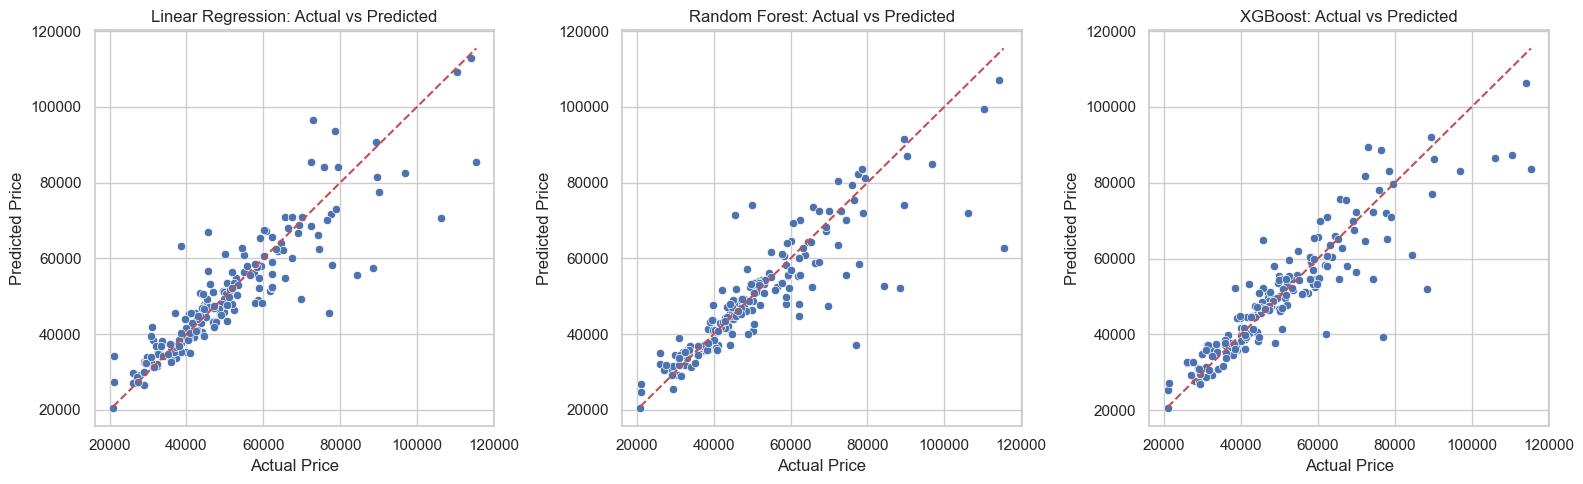

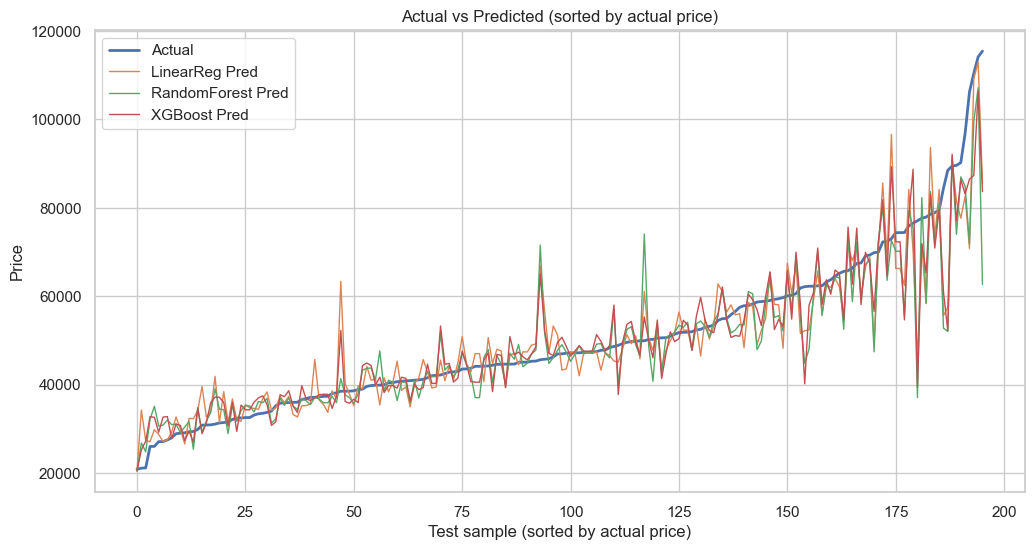

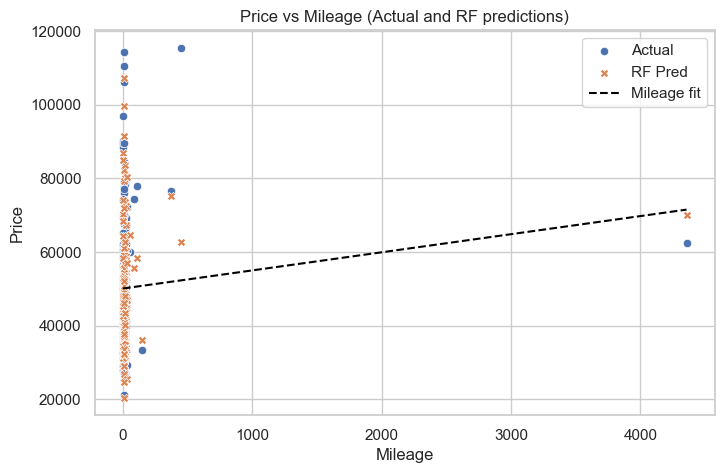


Saved predictions to model_predictions_comparison.csv


In [23]:
# === Add these imports at top of your script if not already present ===
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
import math

# =========================
# 1) Train Linear Regression (pipeline)
# =========================
lr_model = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("lr", LinearRegression())
])

print("\nTraining Linear Regression (baseline)...")
lr_model.fit(X_train, y_train)

# Extract the trained linear regression (the final estimator)
lr = lr_model.named_steps['lr']

# To print regression equation we need the feature names after preprocessing
# Fit preprocessor separately to get transformed feature names
preprocessor.fit(X_train)

# numeric feature names are numeric_cols
num_features = numeric_cols.copy()

# one-hot feature names: fetch OneHotEncoder from the preprocessor
# Note: this depends on ColumnTransformer named 'cat' and OneHotEncoder inside
ohe = preprocessor.named_transformers_['cat'].named_steps['onehot']
ohe_feature_names = list(ohe.get_feature_names_out(categorical_cols))

feature_names = num_features + ohe_feature_names

# Transform X_train to get shape check (optional)
# X_train_trans = preprocessor.transform(X_train)

# Get coefficients and intercept
coefs = lr.coef_
intercept = lr.intercept_

# If lengths mismatch, print caution. Usually they match.
if len(coefs) != len(feature_names):
    print(f"WARNING: #coefs ({len(coefs)}) != #features ({len(feature_names)})")
else:
    # Print a readable linear equation: price = intercept + sum(coef_i * feature_i)
    eq_terms = [f"({intercept:.2f})"]
    print("\n=== Linear Regression Equation ===")
    print(f"Intercept: {intercept:.4f}")
    # Print top positive and negative coefficients and full mapping optionally
    coef_df = pd.DataFrame({
        'feature': feature_names,
        'coefficient': coefs
    }).sort_values(by='coefficient', ascending=False).reset_index(drop=True)
    # Print full equation (limited to top 30 for readability)
    print("\nTop 15 positive coefficients:")
    print(coef_df.head(15).to_string(index=False))
    print("\nTop 15 negative coefficients:")
    print(coef_df.tail(15).sort_values(by='coefficient').to_string(index=False))

# =========================
# 2) Make Predictions for all models
# =========================
y_pred_lr = lr_model.predict(X_test)
y_pred_rf = rf_model.predict(X_test)
y_pred_xgb = xgb_model.predict(X_test)

# Put results in a dataframe for easy inspection
predictions_df = X_test.copy().reset_index(drop=True)
predictions_df['actual_price'] = y_test.reset_index(drop=True)
predictions_df['pred_lr'] = y_pred_lr
predictions_df['pred_rf'] = y_pred_rf
predictions_df['pred_xgb'] = y_pred_xgb

# Print sample
print("\nSample predictions:")
print(predictions_df[['actual_price','pred_lr','pred_rf','pred_xgb']].head())

# =========================
# 3) Evaluation metrics
# =========================
def print_metrics(name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_true, y_pred)
    print(f"\n{name} -> MAE: {mae:.2f}, RMSE: {rmse:.2f}, R2: {r2:.4f}")
    return {'model': name, 'MAE': mae, 'RMSE': rmse, 'R2': r2}

results = []
results.append(print_metrics("LinearRegression", y_test, y_pred_lr))
results.append(print_metrics("RandomForest", y_test, y_pred_rf))
results.append(print_metrics("XGBoost", y_test, y_pred_xgb))

results_df = pd.DataFrame(results).sort_values(by='RMSE')
print("\nModel comparison (by RMSE):")
print(results_df)

# =========================
# 4) Feature importance for RF and XGB (and approximate for LR)
# =========================
# For RF and XGB we need the model step from the pipeline
rf_estimator = rf_model.named_steps['model']
xgb_estimator = xgb_model.named_steps['model']

# Since preprocessor one-hot expanded categorical features, we use the same feature_names above
# Get RF importances on transformed features (approximate)
rf_importances = rf_estimator.feature_importances_
xgb_importances = xgb_estimator.feature_importances_

fi_df = pd.DataFrame({
    'feature': feature_names,
    'rf_importance': rf_importances,
    'xgb_importance': xgb_importances
}).fillna(0)

# show top 15 by RF
print("\nTop features by Random Forest importance:")
print(fi_df.sort_values('rf_importance', ascending=False).head(15).to_string(index=False))

print("\nTop features by XGBoost importance:")
print(fi_df.sort_values('xgb_importance', ascending=False).head(15).to_string(index=False))

# =========================
# 5) Plot Actual vs Predicted (scatter) for all models
# =========================
plt.figure(figsize=(16,5))

plt.subplot(1,3,1)
sns.scatterplot(x=y_test, y=y_pred_lr)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Linear Regression: Actual vs Predicted")

plt.subplot(1,3,2)
sns.scatterplot(x=y_test, y=y_pred_rf)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Random Forest: Actual vs Predicted")

plt.subplot(1,3,3)
sns.scatterplot(x=y_test, y=y_pred_xgb)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("XGBoost: Actual vs Predicted")

plt.tight_layout()
plt.show()

# =========================
# 6) Sorted Actual vs Predicted line plots for direct comparison
# =========================
sorted_df = predictions_df.sort_values('actual_price').reset_index(drop=True)
plt.figure(figsize=(12,6))
plt.plot(sorted_df['actual_price'].values, label='Actual', linewidth=2)
plt.plot(sorted_df['pred_lr'].values, label='LinearReg Pred', linewidth=1)
plt.plot(sorted_df['pred_rf'].values, label='RandomForest Pred', linewidth=1)
plt.plot(sorted_df['pred_xgb'].values, label='XGBoost Pred', linewidth=1)
plt.xlabel("Test sample (sorted by actual price)")
plt.ylabel("Price")
plt.title("Actual vs Predicted (sorted by actual price)")
plt.legend()
plt.show()

# =========================
# 7) Single-feature plot: Price vs Mileage with Linear fit (for intuition)
#    We'll use the test set for plotting; we need numeric 'mileage' in predictions_df.
# =========================
if 'mileage' in predictions_df.columns:
    plt.figure(figsize=(8,5))
    sns.scatterplot(x=predictions_df['mileage'], y=predictions_df['actual_price'], label='Actual')
    sns.scatterplot(x=predictions_df['mileage'], y=predictions_df['pred_rf'], label='RF Pred', marker='X')
    # Fit a simple linear regression on mileage -> price for visualization
    m = LinearRegression()
    # mileage may need reshape
    X_mileage = predictions_df['mileage'].values.reshape(-1,1)
    # handle any missing (should be imputed earlier)
    mask = ~np.isnan(X_mileage).ravel()
    m.fit(X_mileage[mask], predictions_df['actual_price'].values[mask])
    mileage_pred_line = m.predict(np.linspace(X_mileage.min(), X_mileage.max(), 100).reshape(-1,1))
    plt.plot(np.linspace(X_mileage.min(), X_mileage.max(), 100), mileage_pred_line, color='black', linestyle='--', label='Mileage fit')
    plt.xlabel("Mileage")
    plt.ylabel("Price")
    plt.title("Price vs Mileage (Actual and RF predictions)")
    plt.legend()
    plt.show()
else:
    print("No 'mileage' column available for single-feature plot.")

# =========================
# 8) Save predictions to CSV for further analysis if needed
# =========================
predictions_df.to_csv("model_predictions_comparison.csv", index=False)
print("\nSaved predictions to model_predictions_comparison.csv")


In [24]:
sns.set(style="whitegrid", context="notebook")


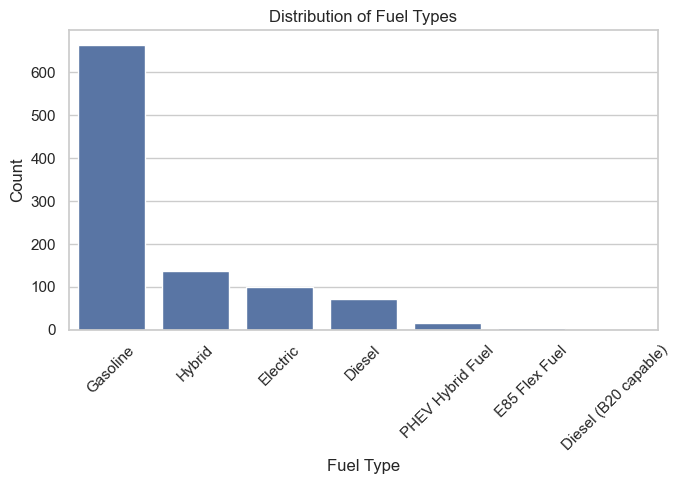

In [25]:
plt.figure(figsize=(7,5))
sns.countplot(data=df, x='fuel', order=df_dropped['fuel'].value_counts().index)
plt.title("Distribution of Fuel Types")
plt.xlabel("Fuel Type")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


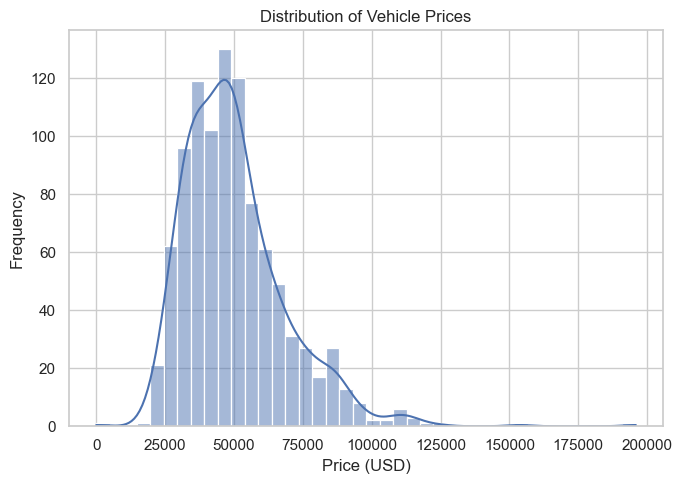

In [26]:
plt.figure(figsize=(7,5))
sns.histplot(df['price'], bins=40, kde=True)
plt.title("Distribution of Vehicle Prices")
plt.xlabel("Price (USD)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()


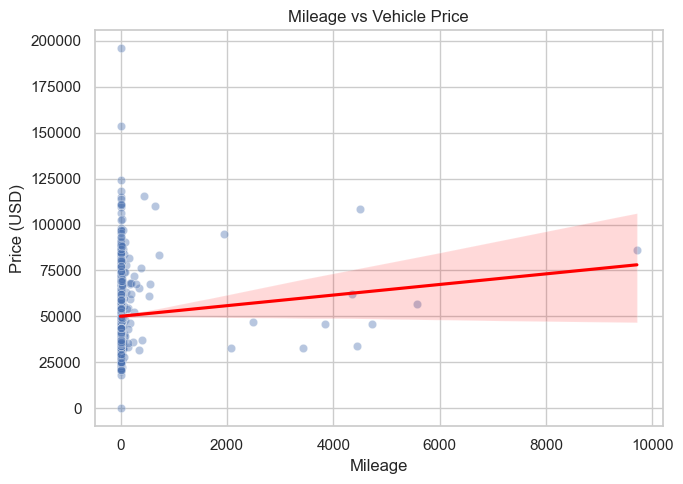

In [27]:
plt.figure(figsize=(7,5))
sns.scatterplot(data=df, x='mileage', y='price', alpha=0.4)
sns.regplot(data=df, x='mileage', y='price', scatter=False, color='red')
plt.title("Mileage vs Vehicle Price")
plt.xlabel("Mileage")
plt.ylabel("Price (USD)")
plt.tight_layout()
plt.show()


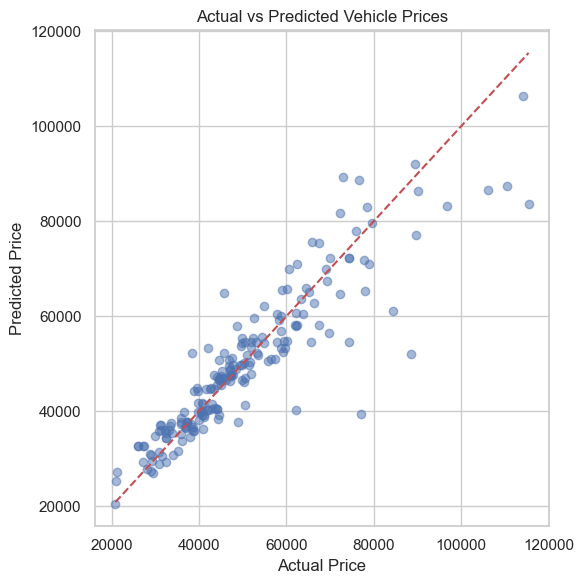

In [29]:
y_test        # actual prices
y_pred_xgb   # predicted prices from best model
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_xgb, alpha=0.5)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)
plt.title("Actual vs Predicted Vehicle Prices")
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.tight_layout()
plt.show()

